# RIVM data of COVID infection

The dataset used is pulled from https://github.com/mzelst/covid-19, which archived data in period from 2020-06-01 to 2023-02-26.

## Tests data

This data is devided by date of statistics and municipality. It can be a good statistics of positive ratio in a fixed region over time.

In [112]:
import pandas as pd

furl_tests = "https://github.com/mzelst/covid-19/raw/master/data-rivm/tests/rivm_daily_2023-04-04.csv.gz"

df_tests = pd.read_csv(furl_tests, compression="gzip", header=0, sep=",", quotechar='"')
df_groningen = df_tests[df_tests["Security_region_name"] == "Groningen"].reset_index(drop=True)
df_groningen

,Version,Date_of_report,Date_of_statistics,Security_region_code,Security_region_name,Tested_with_result,Tested_positive
0,4,2022-09-02T09:00:00Z,2020-06-01,VR01,Groningen,3,0
1,4,2022-09-02T09:00:00Z,2020-06-02,VR01,Groningen,207,0
2,4,2022-09-02T09:00:00Z,2020-06-03,VR01,Groningen,207,0
3,4,2022-09-02T09:00:00Z,2020-06-04,VR01,Groningen,241,1
4,4,2022-09-02T09:00:00Z,2020-06-05,VR01,Groningen,224,0
...,...,...,...,...,...,...,...
1015,4,2023-03-21T09:00:00Z,2023-03-13,VR01,Groningen,5,3
1016,4,2023-03-21T09:00:00Z,2023-03-14,VR01,Groningen,8,5
1017,4,2023-03-21T09:00:00Z,2023-03-15,VR01,Groningen,2,1
1018,4,2023-03-21T09:00:00Z,2023-03-16,VR01,Groningen,7,2


<Axes: xlabel='Date_of_statistics'>

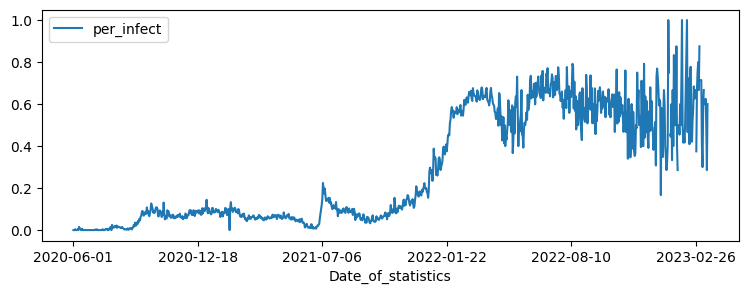

In [118]:
# perday statistics
df_groningen["per_infect"] = df_groningen['Tested_positive'] / df_groningen['Tested_with_result']
df_groningen.plot.line(x="Date_of_statistics", y="per_infect", figsize=(9, 3))

<Axes: xlabel='Date_of_statistics'>

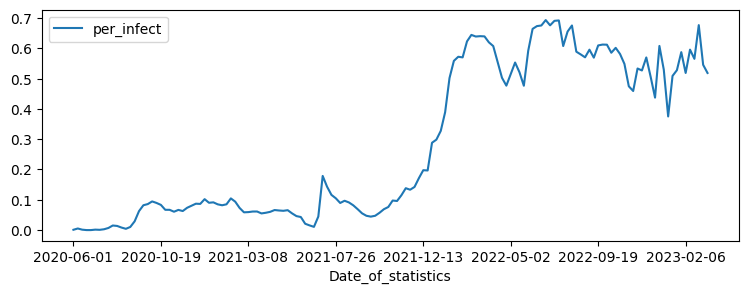

In [125]:
# perweek statistics
df_groningen_week = df_groningen.groupby(df_groningen.index // 7).agg({
    "Tested_positive": "sum", 
    "Tested_with_result": "sum", 
    "Date_of_statistics": lambda x: x.iloc[0]
})
df_groningen_week["per_infect"] = df_groningen_week["Tested_positive"] / df_groningen_week["Tested_with_result"]
df_groningen_week.plot.line(x="Date_of_statistics", y="per_infect", figsize=(9, 3))

In [126]:
# select period
df_selected = df_groningen_week.copy(deep=True)
df_selected["Date_of_statistics"] = pd.to_datetime(df_selected["Date_of_statistics"])
df_selected = df_selected.set_index(["Date_of_statistics"])

<Axes: xlabel='Date_of_statistics'>

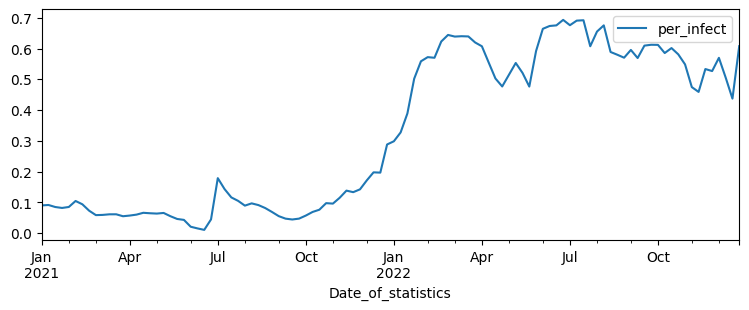

In [127]:
df_selected = df_selected["2021-01-01":"2023-01-01"]
df_selected.plot.line(y="per_infect", figsize=(9, 3))

## Infectieradar daily data
This is from the app recommended by the government, exactly for collecting the information of infect ratio. This data is available from 2020-11-01 to 2023-05-22.

In [93]:
furl_infectieradar = "https://github.com/mzelst/covid-19/raw/master/data-rivm/infectieradar/infectieradar_daily_2023-05-22.csv"

df_infectierader = pd.read_csv(furl_infectieradar)
df_infectierader["Date_of_statistics"] = pd.to_datetime(df_infectierader["Date_of_statistics"])
df_infectierader = df_infectierader.set_index("Date_of_statistics")
df_infectierader["Perc_covid_symptoms"] = df_infectierader["Perc_covid_symptoms"].apply(lambda x: str(x).replace(",", ".")).astype(float)
df_infectierader

,Version,Date_of_report,Perc_covid_symptoms,MA_perc_covid_symptoms
Date_of_statistics,,,,
2020-11-01,1,2023-05-23T10:00:00Z,2.74,NaN
2020-11-02,1,2023-05-23T10:00:00Z,2.33,NaN
2020-11-03,1,2023-05-23T10:00:00Z,3.11,NaN
2020-11-04,1,2023-05-23T10:00:00Z,3.73,"3,09"
2020-11-05,1,2023-05-23T10:00:00Z,3.70,"3,10"
...,...,...,...,...
2023-05-18,1,2023-05-23T10:00:00Z,2.12,"2,35"
2023-05-19,1,2023-05-23T10:00:00Z,2.26,"2,33"
2023-05-20,1,2023-05-23T10:00:00Z,2.34,NaN


<Axes: xlabel='Date_of_statistics'>

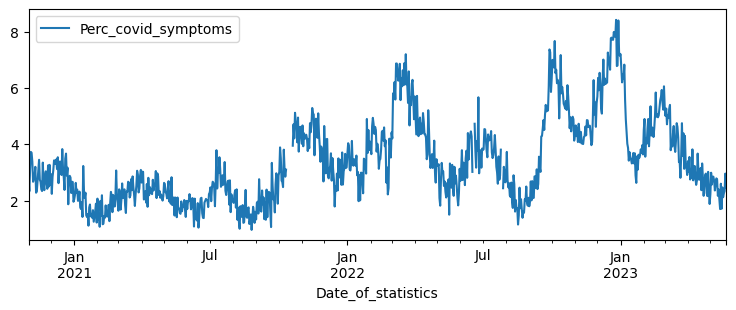

In [94]:
df_infectierader.plot.line(y="Perc_covid_symptoms", figsize=(9, 3))

## Dashboard data

Tests data further devided by age, category, etc., which may helps generate data that better fits to the reality.

In [230]:
# positive rate by age groups

furl_age = "https://github.com/mzelst/covid-19/raw/master/data-dashboards/positieve-testen-per-week-per-leeftijdsgroep.csv"

df_age = pd.read_csv(furl_age)
df_age

,Jaar,Week,CohortGenormaliseerd,CohortOrigineel,AantalTesten,AantalPositief,PercentagePositief
0,2020,30,0-20,0-4,361,1,0.277008
1,2020,30,0-20,10-14,3011,17,0.564596
2,2020,30,0-20,15-19,6009,72,1.198203
3,2020,30,0-20,5-9,1219,7,0.574241
4,2020,30,20-29,20-24,9335,142,1.521157
...,...,...,...,...,...,...,...
577,2021,11,40-49,40 - 49,73794,6089,8.251348
578,2021,11,50-59,50 - 59,56933,6287,11.042805
579,2021,11,60-69,60 - 69,42908,3841,8.951711
580,2021,11,70+,70+,24107,2505,10.391173


In [234]:
# for age group 20-29
from datetime import datetime

df_age_group = df_age[df_age["CohortGenormaliseerd"] == "20-29"]
df_age_group["Monday_of_week"] = df_age_group[["Jaar", "Week"]].apply(lambda x: str(x["Jaar"]) + "-W" + str(x["Week"]), axis=1)
df_age_group["Monday_of_week"] = df_age_group["Monday_of_week"].apply(lambda x: datetime.strptime(x + "-1", "%Y-W%W-%w").date())
df_age_group = df_age_group.groupby(by=["Jaar", "Week"], as_index=False).agg({
    "Monday_of_week": lambda x: x.iloc[0], 
    "AantalTesten": "sum", 
    "AantalPositief": "sum"
})
df_age_group["per_positive"] = df_age_group["AantalPositief"] / df_age_group["AantalTesten"]
df_age_group

/tmp/ipykernel_16619/1309349487.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age_group["Monday_of_week"] = df_age_group[["Jaar", "Week"]].apply(lambda x: str(x["Jaar"]) + "-W" + str(x["Week"]), axis=1)
/tmp/ipykernel_16619/1309349487.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age_group["Monday_of_week"] = df_age_group["Monday_of_week"].apply(lambda x: datetime.strptime(x + "-1", "%Y-W%W-%w").date())


,Jaar,Week,Monday_of_week,AantalTesten,AantalPositief,per_positive
0,2020,30,2020-07-27,20132,269,0.013362
1,2020,31,2020-08-03,22890,606,0.026474
2,2020,32,2020-08-10,31592,1202,0.038048
3,2020,33,2020-08-17,30749,1586,0.051579
4,2020,34,2020-08-24,38192,1335,0.034955
5,2020,35,2020-08-31,39435,1383,0.035070
6,2020,36,2020-09-07,23375,1450,0.062032
7,2020,37,2020-09-14,32962,2379,0.072174
8,2020,38,2020-09-21,34136,3149,0.092249
9,2020,39,2020-09-28,39508,3905,0.098841


<Axes: xlabel='Monday_of_week'>

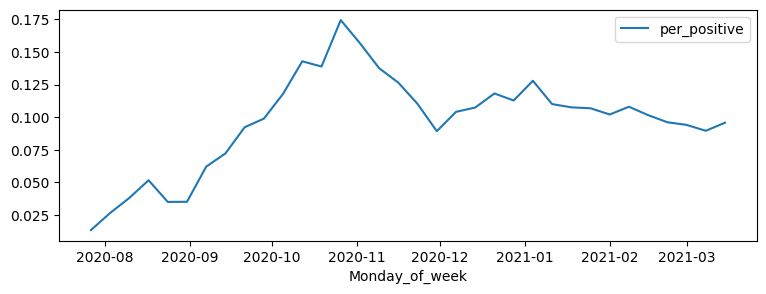

In [235]:
# Tried out different age groups, but no significant difference shown on trends
# peek values are slightly different though.
df_age_group.plot.line(x="Monday_of_week", y="per_positive", figsize=(9, 3))